# Volatility Regime Analysis

## Objective

Determine whether Momentum126 performance depends on market volatility.

Research Questions:

- Does momentum work better in calm markets?
- Does momentum work better in volatile markets?
- Can volatility be used as a strategy filter?

Strategy:

- NIFTY 500 Universe
- Momentum126
- Top 20 Stocks
- Equal Weight
- 42-Day Rebalance
- 0.10% Transaction Cost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

close = pd.read_pickle(
    "../data/nifty500_close_clean.pkl"
)

mom126 = (
    close
    .pct_change(126)
    .shift(1)
)

In [3]:
market_returns = (
    close
    .pct_change()
    .mean(axis=1)
)

market_vol = (
    market_returns
    .rolling(63)
    .std()
)

In [4]:
low_threshold = market_vol.quantile(0.33)

high_threshold = market_vol.quantile(0.67)

vol_regime = pd.Series(
    index=market_vol.index,
    dtype="object"
)

vol_regime[
    market_vol <= low_threshold
] = "Low"

vol_regime[
    market_vol >= high_threshold
] = "High"

vol_regime[
    (market_vol > low_threshold)
    &
    (market_vol < high_threshold)
] = "Medium"

vol_regime.value_counts()

Medium    901
Low       876
High      876
Name: count, dtype: int64

In [5]:
rebalance_dates = close.index[126::42]

strategy_returns = []

for i in range(len(rebalance_dates)-1):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    selected = (
        mom126.loc[start]
        .dropna()
        .nlargest(20)
        .index
    )

    gross = (
        close.loc[end, selected]
        /
        close.loc[start, selected]
        - 1
    ).mean()

    strategy_returns.append(
        gross - 0.001
    )

strategy_returns = pd.Series(
    strategy_returns,
    index=rebalance_dates[:-1]
)

In [6]:
vol_df = pd.DataFrame({
    "Return": strategy_returns,
    "Volatility": vol_regime.loc[
        strategy_returns.index
    ]
})

vol_df.head()

,Return,Volatility
Date,,
2015-07-07,NaN,Medium
2015-09-03,0.045079,High
2015-11-06,0.087841,High
2016-01-11,-0.141215,Low
2016-03-11,0.118566,High


## Volatility Regime Classification

Market volatility is estimated using the rolling 63-day volatility of the equal-weight NIFTY500 market proxy.

Regimes:

- Low Volatility
- Medium Volatility
- High Volatility

Objective:

Determine whether Momentum126 performs differently across volatility environments.

In [7]:
summary = vol_df.groupby(
    "Volatility"
)["Return"].agg(
    ["count","mean","std"]
)

summary["Sharpe"] = (
    summary["mean"]
    /
    summary["std"]
)

summary

,count,mean,std,Sharpe
Volatility,,,,
High,20,0.091600,0.109584,0.835895
Low,19,0.064719,0.163828,0.395045
Medium,21,0.053556,0.098273,0.544976


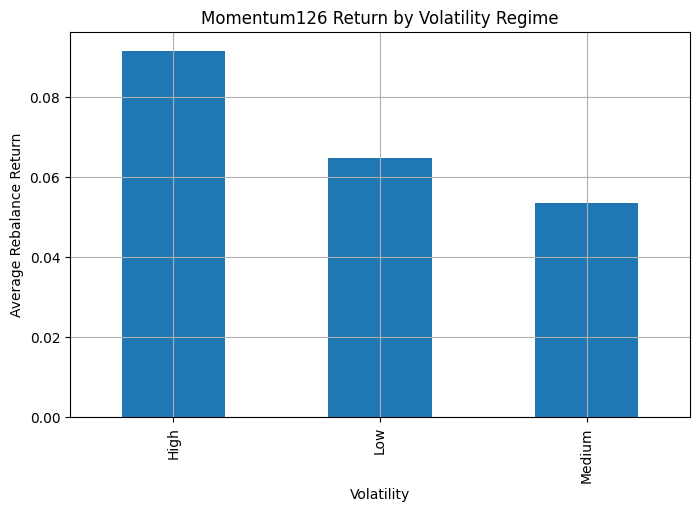

In [8]:
summary["mean"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title(
    "Momentum126 Return by Volatility Regime"
)

plt.ylabel(
    "Average Rebalance Return"
)

plt.grid(True)

plt.show()

## Volatility Filter Strategy

Hypothesis:

If momentum performs best during specific volatility regimes, portfolio exposure can be restricted to those environments.

Method:

- Invest only during the selected volatility regime.
- Remain in cash otherwise.
- Compare against the baseline Momentum126 strategy.

In [9]:
filtered_returns = []

rebalance_dates = close.index[126::42]

for i in range(len(rebalance_dates)-1):

    start = rebalance_dates[i]
    end = rebalance_dates[i+1]

    current_vol = vol_regime.loc[start]

    if current_vol != "High":

        filtered_returns.append(0)

        continue

    selected = (
        mom126.loc[start]
        .dropna()
        .nlargest(20)
        .index
    )

    gross = (
        close.loc[end, selected]
        /
        close.loc[start, selected]
        - 1
    ).mean()

    filtered_returns.append(
        gross - 0.001
    )

filtered_returns = pd.Series(
    filtered_returns,
    index=rebalance_dates[:-1]
)

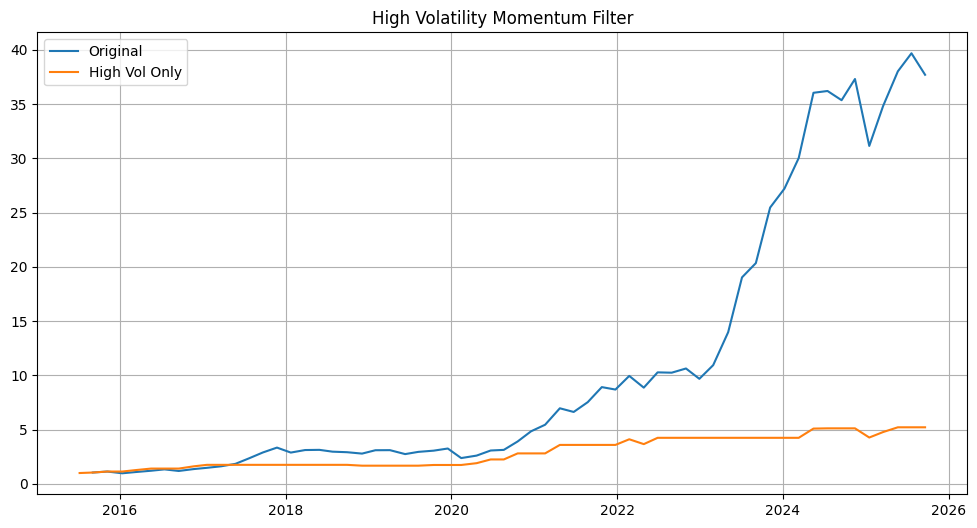

In [12]:
original_equity = (
    1 + strategy_returns
).cumprod()

filtered_equity = (
    1 + filtered_returns
).cumprod()

plt.figure(figsize=(12,6))

plt.plot(
    original_equity,
    label="Original"
)

plt.plot(
    filtered_equity,
    label="High Vol Only"
)

plt.legend()

plt.title(
    "High Volatility Momentum Filter"
)

plt.grid(True)

plt.savefig(
    "../results/plots/07_volatility_regime_returns.png",
    bbox_inches="tight"
)

plt.show()

In [11]:
summary.to_csv(
    "../results/tables/07_volatility_regime_stats.csv"
)



## Conclusion

Results indicate that momentum performance varies across volatility environments.

While high-volatility periods exhibited stronger average returns, restricting exposure solely to these periods reduced overall portfolio performance.

Volatility regimes provide useful descriptive information but do not improve the baseline strategy when used as a hard filter.